## Polynomial Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Text(0, 0.5, 'Y dataset')

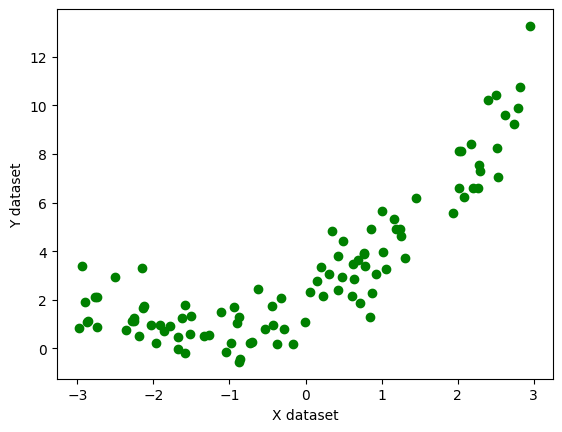

In [3]:
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + 1.5*X + 2 + np.random.randn(100, 1)
# quadratic equation used - y=0.5x^2+1.5x+2+outliers
plt.scatter(X,y, color='g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Simple Linear Regression
from sklearn.linear_model import LinearRegression

regression_1 = LinearRegression()

In [11]:
regression_1.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
from sklearn.metrics import r2_score

score = r2_score(y_test, regression_1.predict(X_test))
print(score)

0.6140791794923548


Text(0, 0.5, 'Y dataset')

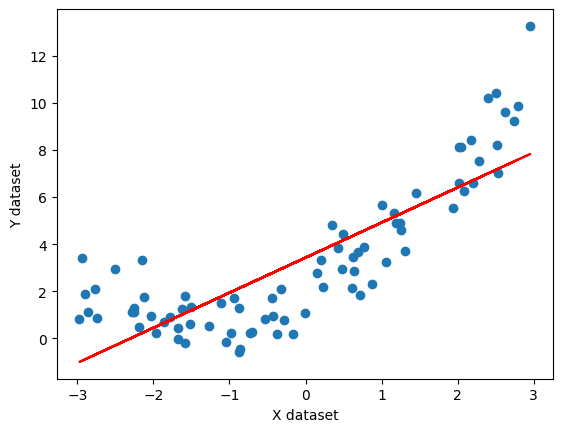

In [13]:
## Visualize
plt.plot(X_train, regression_1.predict(X_train), color='r')
plt.scatter(X_train, y_train)
plt.xlabel("X dataset")
plt.ylabel("Y dataset")

In [22]:
# Polynomial Transformation

from sklearn.preprocessing import PolynomialFeatures

In [24]:
poly = PolynomialFeatures(degree=2, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [26]:
X_train_poly
# 1.00000000e+00 - bais
# 2.52506244e+00 -x1
# 6.37594030e+00 - x1^2

array([[ 1.00000000e+00,  2.52506244e+00,  6.37594030e+00],
       [ 1.00000000e+00,  2.31142229e-01,  5.34267302e-02],
       [ 1.00000000e+00,  1.05896712e+00,  1.12141137e+00],
       [ 1.00000000e+00, -7.04768205e-01,  4.96698223e-01],
       [ 1.00000000e+00,  2.02325272e+00,  4.09355155e+00],
       [ 1.00000000e+00, -7.24014569e-01,  5.24197097e-01],
       [ 1.00000000e+00,  6.87676962e-01,  4.72899604e-01],
       [ 1.00000000e+00,  7.72874627e-01,  5.97335189e-01],
       [ 1.00000000e+00, -1.04596071e+00,  1.09403381e+00],
       [ 1.00000000e+00, -2.86540837e+00,  8.21056513e+00],
       [ 1.00000000e+00, -2.77398295e+00,  7.69498143e+00],
       [ 1.00000000e+00, -1.26837554e+00,  1.60877652e+00],
       [ 1.00000000e+00, -9.86479670e-01,  9.73142139e-01],
       [ 1.00000000e+00,  1.31135514e+00,  1.71965230e+00],
       [ 1.00000000e+00,  2.27551889e+00,  5.17798623e+00],
       [ 1.00000000e+00,  1.44895571e+00,  2.09947266e+00],
       [ 1.00000000e+00, -1.59150835e+00

In [28]:
from sklearn.metrics import r2_score

regression_2 = LinearRegression()
regression_2.fit(X_train_poly, y_train)
y_pred = regression_2.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score) 

0.8809524744766952


In [30]:
print(regression_2.coef_)

[[0.         1.54076234 0.54754741]]


In [31]:
print(regression_2.intercept_)

[1.83063917]


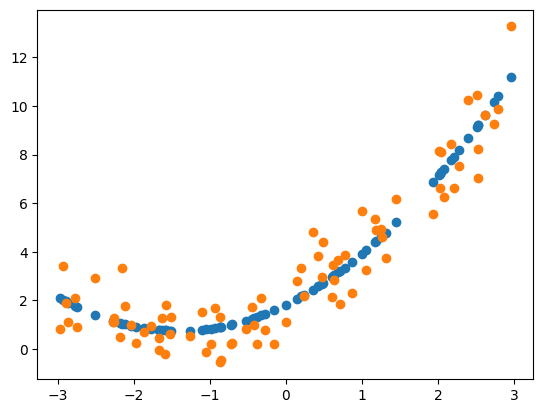

In [33]:
plt.scatter(X_train, regression_2.predict(X_train_poly))
plt.scatter(X_train, y_train)

### Degree = 3

In [34]:
poly = PolynomialFeatures(degree=3, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [35]:
X_train_poly

array([[ 1.00000000e+00,  2.52506244e+00,  6.37594030e+00,
         1.60996473e+01],
       [ 1.00000000e+00,  2.31142229e-01,  5.34267302e-02,
         1.23491735e-02],
       [ 1.00000000e+00,  1.05896712e+00,  1.12141137e+00,
         1.18753777e+00],
       [ 1.00000000e+00, -7.04768205e-01,  4.96698223e-01,
        -3.50057115e-01],
       [ 1.00000000e+00,  2.02325272e+00,  4.09355155e+00,
         8.28228929e+00],
       [ 1.00000000e+00, -7.24014569e-01,  5.24197097e-01,
        -3.79526335e-01],
       [ 1.00000000e+00,  6.87676962e-01,  4.72899604e-01,
         3.25202163e-01],
       [ 1.00000000e+00,  7.72874627e-01,  5.97335189e-01,
         4.61665212e-01],
       [ 1.00000000e+00, -1.04596071e+00,  1.09403381e+00,
        -1.14431638e+00],
       [ 1.00000000e+00, -2.86540837e+00,  8.21056513e+00,
        -2.35266221e+01],
       [ 1.00000000e+00, -2.77398295e+00,  7.69498143e+00,
        -2.13457473e+01],
       [ 1.00000000e+00, -1.26837554e+00,  1.60877652e+00,
      

In [36]:
from sklearn.metrics import r2_score

regression_3 = LinearRegression()
regression_3.fit(X_train_poly, y_train)
y_pred = regression_3.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score) 

0.8776704631166751


In [40]:
# Prediction of new dataset
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

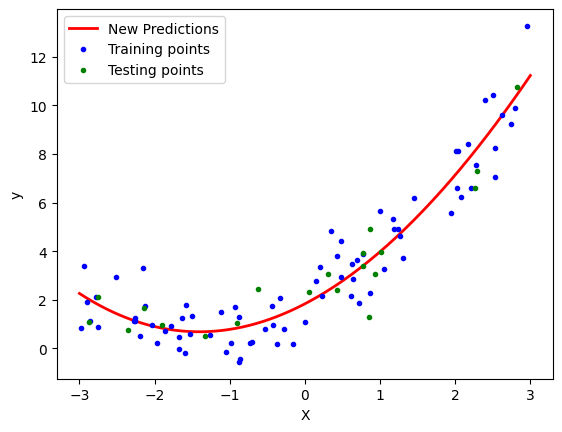

: 

In [ ]:
y_new = regression_3.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label="New Predictions")
plt.plot(X_train, y_train, "b.", label="Training points")
plt.plot(X_test, y_test, "g.", label="Testing points")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()